- Entradas: "PwmD", "PwmE", "sPwm", "dPwm"
- Saida: Theta
- Loss = L_d + L_p 


In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from keras import initializers
from keras import regularizers
import joblib
import os

TITLES = ["Train_1", "Train_2", "Val_1", "Val_2", "Test_1", "Test_2", "LSG_1", "LSG_2"]

PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm"]
TARGETS = ["Theta"]
  
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGETS) 

TS = 0.07
TIME_STEPS = 15
BATCH_SIZE = 32
PLOT = True

In [8]:
Datasets = []
for title in TITLES:
    df = pd.read_excel("./../../../00-Data/SavgolDatasets.xlsx", sheet_name=title)
    Datasets.append(df)

In [10]:
for i in range(len(Datasets)):
    Dataset = Datasets[i].copy()

    for var in TARGETS:
        Dataset[f"d{var}"] = (Dataset[var].shift(-1) - Dataset[var]) / TS
    
    Dataset["sPwm"] = Dataset["PwmD"] + Dataset["PwmE"]
    Dataset["dPwm"] = Dataset["PwmD"] - Dataset["PwmE"]

    Dataset = Dataset.dropna(subset=[f"d{var}" for var in TARGETS])

    Datasets[i] = Dataset

In [11]:
# =========================
# LOAD TREINO
# ========================

df_train = pd.concat([Datasets[0], Datasets[1]])

Out_train = df_train[TARGETS].values
dOut_train = df_train[[f"d{t}" for t in TARGETS]].values
Inp_train = df_train[PREDICTORS].values

# =========================
# LOAD VAL
# =========================
df_val = pd.concat([Datasets[2], Datasets[3]])

dOut_val = df_val[[f"d{t}" for t in TARGETS]].values
Inp_val = df_val[PREDICTORS].values

# =========================
# LOAD Physics
# =========================
Theta = df_train["Theta"].values
Wd = df_train["Wd"].values
We = df_train["We"].values

In [12]:
# =========================
# NORMALIZAÇÃO 
# =========================
InpScaler = StandardScaler()
OutScaler = StandardScaler()

Inp_train = InpScaler.fit_transform(Inp_train)
dOut_train = OutScaler.fit_transform(dOut_train.reshape(-1, 1)).flatten()

Inp_val = InpScaler.transform(Inp_val)
dOut_val  = OutScaler.transform(dOut_val.reshape(-1, 1)).flatten()


In [13]:
os.makedirs("./scalers", exist_ok=True)
os.makedirs("./Data", exist_ok=True)

with pd.ExcelWriter("./Data/Datasets.xlsx", engine="openpyxl") as writer:
    for title, Dataset in zip(TITLES, Datasets):
        Dataset.to_excel(writer, sheet_name=title[:31], index=False)
        
joblib.dump(InpScaler, "./scalers/scaler.pkl")
joblib.dump(OutScaler, "./scalers/out_scaler.pkl")

['./scalers/out_scaler.pkl']

In [14]:
def create_sequences(pred, target, time_steps):
    Xs, ys = [], []
    for i in range(len(pred) - time_steps):
        Xs.append(pred[i:i+time_steps])
        ys.append(target[i+time_steps])
    return np.array(Xs), np.array(ys)

In [15]:
# =========================
# Sequencias 
# =========================
Inp_train, dOut_train = create_sequences(Inp_train, dOut_train, TIME_STEPS)
Inp_val, dOut_val = create_sequences(Inp_val, dOut_val, TIME_STEPS)

Wd_p, _     = create_sequences(Wd, Wd, TIME_STEPS)
We_p, _     = create_sequences(We, We, TIME_STEPS)
Theta_p, _  = create_sequences(Theta, Theta, TIME_STEPS)

In [16]:
print("=== SHAPES APÓS SEQUÊNCIAS ===")

print("Inp_val:", Inp_val.shape)
print("dOut_val:", dOut_val.shape)

print("Inp_train:", Inp_train.shape)
print("dOut_train:", dOut_train.shape)
print("Wd_p:", Wd_p.shape)
print("We_p:", We_p.shape)
print("Theta_p:", Theta_p.shape)

=== SHAPES APÓS SEQUÊNCIAS ===
Inp_val: (1947, 15, 4)
dOut_val: (1947,)
Inp_train: (1935, 15, 4)
dOut_train: (1935,)
Wd_p: (1935, 15)
We_p: (1935, 15)
Theta_p: (1935, 15)


$$ \dot{\theta} = \frac{R}{2L} (\phi_d - \phi_e) $$
$$ \dot{x} = \frac{R}{2} (\phi_d + \phi_e) (\cos(\theta))$$
$$ \dot{y} = \frac{R}{2} (\phi_d + \phi_e) (\sin(\theta)) $$

In [17]:
mean_tf = tf.constant(OutScaler.mean_[0], dtype=tf.float32)
std_tf  = tf.constant(OutScaler.scale_[0], dtype=tf.float32) 
 
Inp_val = tf.convert_to_tensor(Inp_val, dtype=tf.float32)
dOut_val = tf.convert_to_tensor(dOut_val, dtype=tf.float32)

Inp_train = tf.convert_to_tensor(Inp_train, dtype=tf.float32)
dOut_train = tf.convert_to_tensor(dOut_train, dtype=tf.float32)

Wd_p = tf.convert_to_tensor(Wd_p, dtype=tf.float32)
We_p = tf.convert_to_tensor(We_p, dtype=tf.float32)
Theta_p = tf.convert_to_tensor(Theta_p, dtype=tf.float32)

In [18]:
R = tf.constant(0.0328, dtype=tf.float32)
L = tf.constant(0.0615, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def CinematicModel(Wd, We, theta):
    outputs = []

    for t in TARGETS:
        if t == "Theta":
            out = (R / (2 * L)) * (Wd - We)
        elif t == "X":
            out = (R / 2) * tf.cos(theta) * (Wd + We)

        elif t == "Y":
            out = (R / 2) * tf.sin(theta) * (Wd + We)
        else:
            raise ValueError(f"Target desconhecido: {t}")

        outputs.append(out)

    return tf.stack(outputs, axis=-1)

In [19]:
def BuildRNN(architecture, recurrent_initializer, initializer, regularizer):

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)))

    for i, units in enumerate(architecture):

        return_sequences = (i < len(architecture) - 1)
        model.add(
            tf.keras.layers.SimpleRNN(
                units,
                activation='tanh',
                kernel_initializer=initializer,
                recurrent_initializer=recurrent_initializer,
                bias_initializer='zeros',
                kernel_regularizer=regularizer,
                recurrent_regularizer=regularizer,
                return_sequences=return_sequences,
            )
        )

    model.add(
        tf.keras.layers.Dense(
            OUTPUT_SIZE,
            activation="linear",
            kernel_initializer=initializer,
            bias_initializer='zeros',
            kernel_regularizer=regularizer,
        )
    )

    return model

In [20]:
@tf.function
def train_step(model, optimizer, Inp, dOut, dOutCin, Ld, Lp):
    # weights = 1 + 3.0 * tf.abs(dOut)
    weights = 1 
    with tf.GradientTape() as tape:
        # FeedForward
        dOut_pred = model(Inp, training=True)
        # Data Loss
        data_loss = tf.reduce_mean(weights * tf.square(dOut_pred - dOut))
        # Physics Loss
        physics_loss = tf.reduce_mean(tf.square(dOut_pred - dOutCin))
        # Loss
        loss = Ld * data_loss + Lp * physics_loss

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return data_loss, physics_loss

In [21]:
def EarlyStopping(model, best_loss, counter, best_weights, min_delta=1e-3):
    dOut_val_pred = model(Inp_val, training=False)
    val_loss = tf.reduce_mean(tf.square(dOut_val_pred - dOut_val))

    if val_loss < (best_loss - min_delta):
        best_loss = val_loss
        counter = 0
        best_weights = model.get_weights()
    else:
        counter += 1

    return best_loss, counter, best_weights, val_loss

def TrainPINN(model, optimizer, Ld, Lp, epochs, Es=False, patience=50):
    best_loss = np.inf
    counter = 0
    best_weights = model.get_weights()

    for epoch in range(epochs):

        loss_d_epoch = []
        loss_f_epoch = []

        for i in range(0, len(Inp_train), BATCH_SIZE):

            Inp_b = Inp_train[i:i+BATCH_SIZE]
            dOut_b = dOut_train[i:i+BATCH_SIZE]
            Theta_b = Theta_p[i:i+BATCH_SIZE]
            Wd_b = Wd_p[i:i+BATCH_SIZE]
            We_b = We_p[i:i+BATCH_SIZE]
        
            # Physics (último passo da sequência)
            dOutCin = CinematicModel(Wd_b[:, -1], We_b[:, -1], Theta_b[:, -1])
            dOutCin = tf.reshape(dOutCin, (-1, 1))
            dOutCin = OutScaler.transform(dOutCin)
        
            ld, lf = train_step(
                model,
                optimizer,
                tf.convert_to_tensor(Inp_b, tf.float32),
                tf.convert_to_tensor(tf.reshape(dOut_b, (-1, 1)), tf.float32),
                tf.convert_to_tensor(dOutCin, tf.float32),
                Ld, 
                Lp
            )

            loss_d_epoch.append(ld.numpy())
            loss_f_epoch.append(lf.numpy())

        if Es == True:
            best_loss, counter, best_weights, val_loss = EarlyStopping(
            model, best_loss, counter, best_weights)
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch} | Ld={np.mean(loss_d_epoch):.4f} | "
                    f"Lf={np.mean(loss_f_epoch):.4f} | Val={val_loss.numpy():.6f}")

            if counter >= patience:
                print(f"\n⛔ Early stopping na época {epoch}")
                break
        else:
            print(f"Epoch {epoch+1} | Ld={np.mean(loss_d_epoch):.4f} | Lf={np.mean(loss_f_epoch):.4f}")

    if Es == True:
        model.set_weights(best_weights)

In [28]:
def PlotOut(ax, title, target_name, y_true, y_pred, y_cin):
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.plot(time, y_true, linestyle='-', linewidth=1.5, color='tab:blue', label='Amostras Reais')
    ax.plot(time, y_pred, linestyle='--', linewidth=1.5, color='tab:orange', label='Valores preditos')
    ax.plot(time, y_cin, linestyle=':', linewidth=2, color='tab:green', label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)


def EvalModel(model):
    n_targets = len(TARGETS)
    if PLOT == True:
        n_datasets = len(Datasets)
        fig, axs = plt.subplots(
                n_datasets,
                2 * n_targets,
                figsize=(6 * 2 * n_targets, 4 * n_datasets)
            )
    

    # estrutura das métricas
    metrics = {
        name: {
            "R2_Train_1": [], "R2_Train_2": [],
            "R2_Val_1": [], "R2_Val_2": [],
            "R2_Test_1": [], "R2_Test_2": [], 
            "R2_LSG_1": [], "R2_LSG_2": [],

            "R2_Train_1_d": [], "R2_Train_2_d": [],
            "R2_Val_1_d": [], "R2_Val_2_d": [],
            "R2_Test_1_d": [], "R2_Test_2_d": [], 
            "R2_LSG_1_d": [], "R2_LSG_2_d": [],
        }
        for name in TARGETS
    }

    for i, Dataset in enumerate(Datasets):
        Out_true = Dataset[TARGETS].values
        dOut_true = Dataset[[f"d{t}" for t in TARGETS]].values
        Inp = Dataset[PREDICTORS].values 
                
        Inp_scaled = InpScaler.transform(Inp)   
        # Sequências
        _, Out_true = create_sequences(Inp_scaled, Out_true, TIME_STEPS)
        Inp, dOut_true = create_sequences(Inp_scaled, dOut_true, TIME_STEPS)

        # Predição
        dOut_pred = model(Inp).numpy()
        dOut_pred = OutScaler.inverse_transform(dOut_pred)

        # Física
        _, Wd = create_sequences(Inp_scaled, Dataset["Wd"].values.astype(np.float32), TIME_STEPS)
        _, We = create_sequences(Inp_scaled, Dataset["We"].values.astype(np.float32), TIME_STEPS)
        _, Theta = create_sequences(Inp_scaled, Dataset["Theta"].values.astype(np.float32), TIME_STEPS)
        dOut_cin = CinematicModel(Wd, We, Theta).numpy()    

        # Reconstrução
        Out_0 = Out_true[TIME_STEPS:][0]
        Out_pred = Out_0 + np.cumsum(dOut_pred * TS, axis=0)
        Out_cin  = Out_0 + np.cumsum(dOut_cin * TS, axis=0)

        # Métricas
        for j, name in enumerate(TARGETS):

            r2_dOut = r2_score(dOut_true[:, j], dOut_pred[:, j])
            r2_Out  = r2_score(Out_true[:, j], Out_pred[:, j])

            metrics[name][f"R2_{TITLES[i]}"].append(r2_Out)
            metrics[name][f"R2_{TITLES[i]}_d"].append(r2_dOut)

            print(f"{name} | {TITLES[i]} -> " f"R² = {r2_Out:.4f}, R2_d = {r2_dOut:.4f}")

            if PLOT == True:
                # 🔹 coluna da posição (y)
                ax_y = axs[i, j] if n_datasets > 1 else axs[j]
                PlotOut(
                    ax_y,
                    TITLES[i],
                    f"{name}",
                    Out_true[:, j],
                    Out_pred[:, j],
                    Out_cin[:, j]
                )

                # 🔹 coluna da derivada (dy)
                ax_dy = axs[i, j + n_targets] if n_datasets > 1 else axs[j + n_targets]
                PlotOut(
                    ax_dy,
                    TITLES[i],
                    f"d{name}",
                    dOut_true[:, j],
                    dOut_pred[:, j],
                    dOut_cin[:, j]
                )
    if PLOT == True:
        plt.tight_layout()

    return metrics

Theta | Train_1 -> R² = 0.8059, R2_d = 0.5167
Theta | Train_2 -> R² = 0.7281, R2_d = 0.6088
Theta | Val_1 -> R² = 0.5587, R2_d = 0.4465
Theta | Val_2 -> R² = 0.7849, R2_d = 0.6084
Theta | Test_1 -> R² = 0.5804, R2_d = 0.5109
Theta | Test_2 -> R² = -6.2025, R2_d = 0.3433
Theta | LSG_1 -> R² = -1.0930, R2_d = 0.5044
Theta | LSG_2 -> R² = -7.7618, R2_d = 0.4469


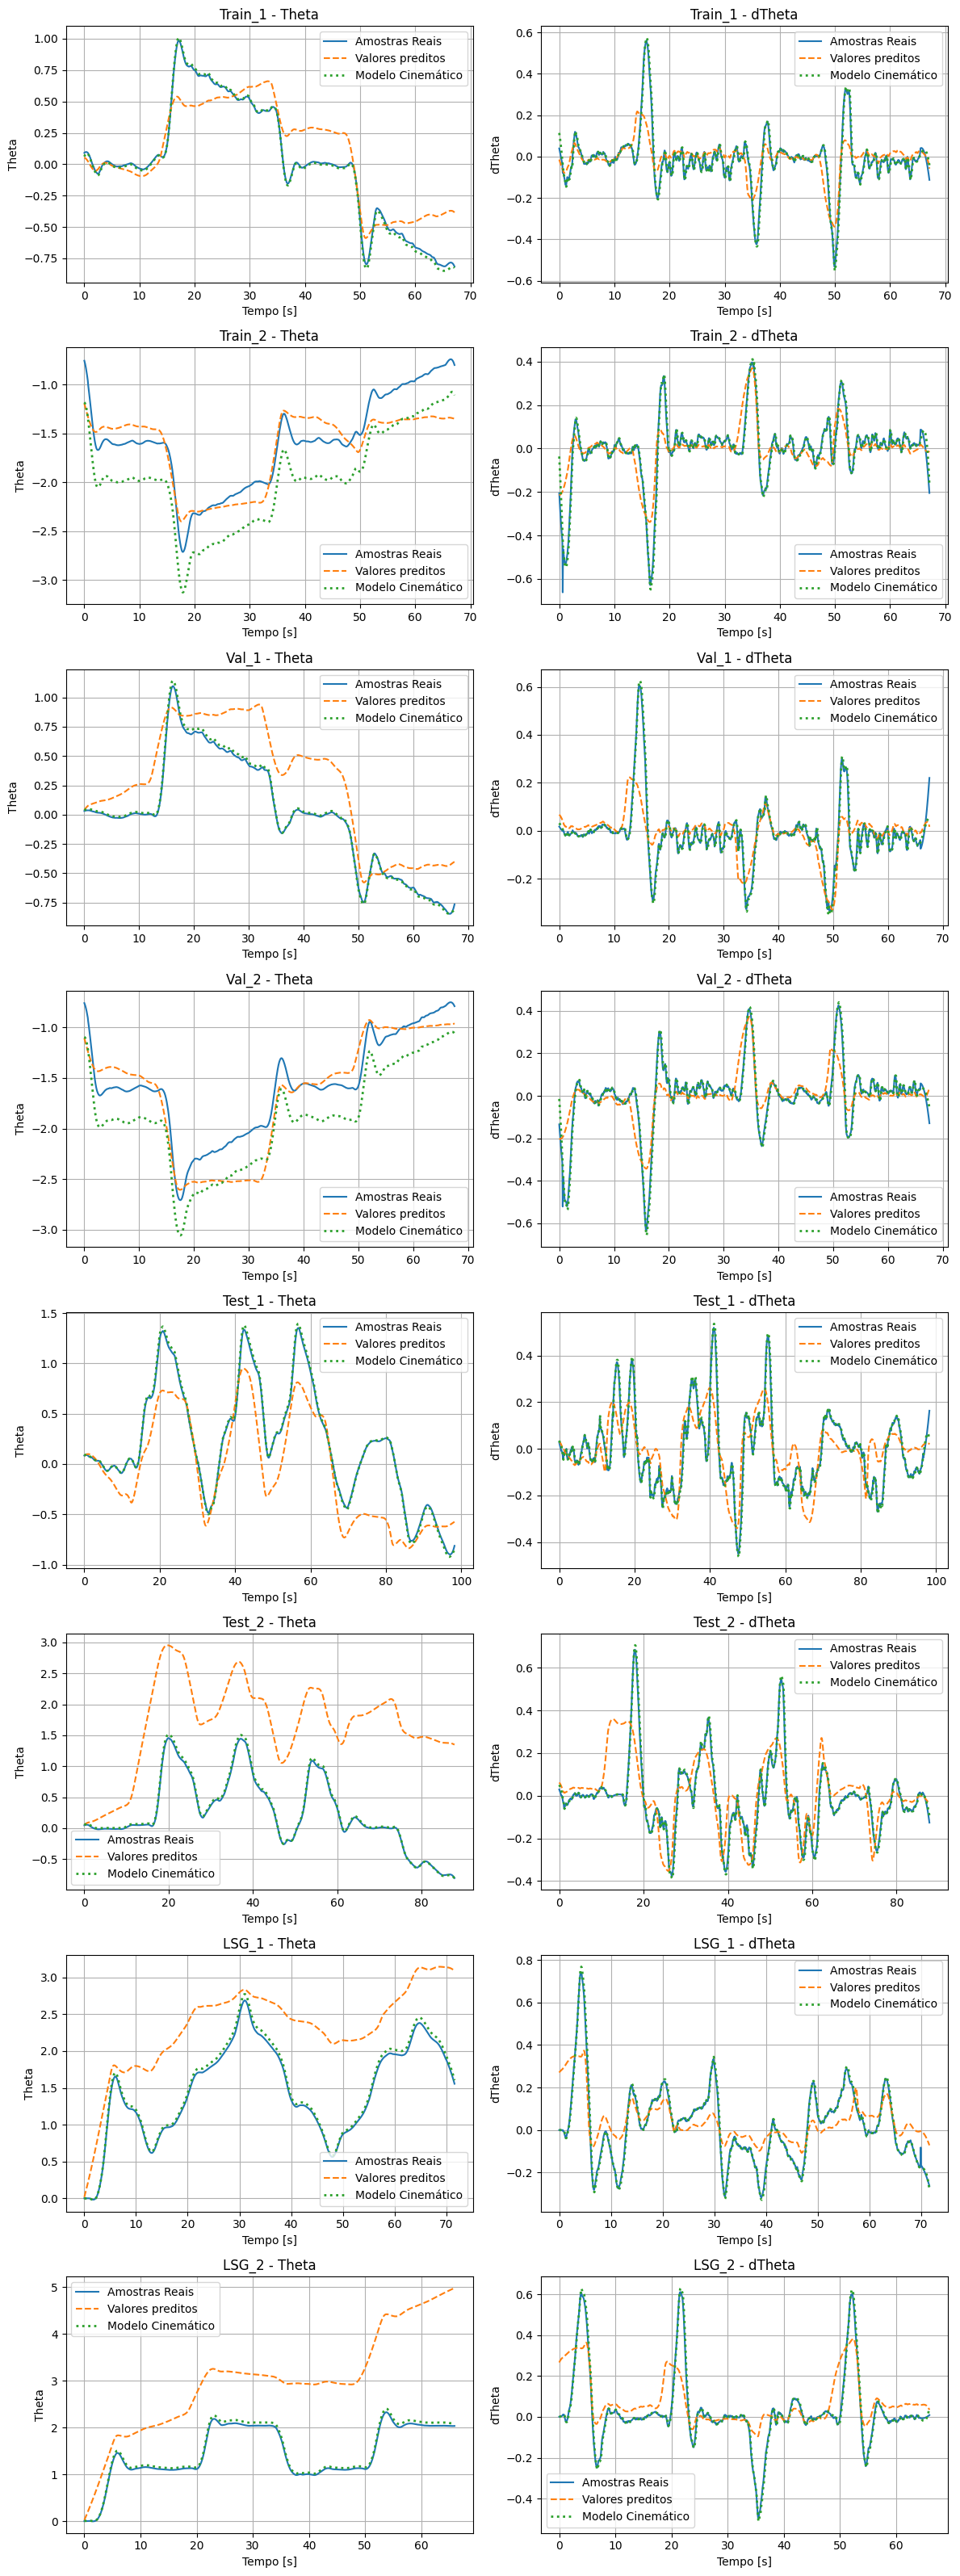

In [29]:
metrics = EvalModel(model)


In [23]:
def to_scalar(x):
    return float(x[0]) if isinstance(x, list) else float(x)

In [24]:
def UpdateRow(metrics, arch, Ld, Lp, r, seed, excel_file):

    model_name = f"model_arch{'-'.join(map(str, arch))}_r{r}_Ld{Ld}_Lp{Lp}_seed{seed}"

    row = {
        "model": model_name,
        "Neurons": arch,
        "Ld": Ld,
        "Lp": Lp,
        "reg": r,
        "seed": seed,
    }

    splits = ["Train", "Val", "Test", "LSG"]
    indices = [1, 2]

    for name in TARGETS:
        for split in splits:
            for idx in indices:
                base_key = f"R2_{split}_{idx}"

                # métrica original (mantida)
                row[f"{base_key}_{name}"] = to_scalar(metrics[name][base_key])

                # métrica com sufixo _d (nova origem)
                row[f"{base_key}_d{name}"] = to_scalar(metrics[name][f"{base_key}_d"])

        df = pd.DataFrame([row])

    try:
        old = pd.read_excel(excel_file)
        new_df = pd.concat([old, df], ignore_index=True)
        new_df.to_excel(excel_file, index=False)
    except FileNotFoundError:
        df.to_excel(excel_file, index=False)

    print(f"Modelo {arch} | Ld={Ld} Lp={Lp} r={r} seed={seed} salvo.")


In [25]:
def ExportModel(model, model_name):

    os.makedirs("weights", exist_ok=True)
    os.makedirs("models", exist_ok=True)

    weights_path = f"weights/{model_name}.weights.h5"
    model_path = f"models/{model_name}.keras"

    model.save_weights(weights_path)
    model.save(model_path)

    print(f"Modelo salvo em:\n{model_path}\n{weights_path}")


Epoch 0 | Ld=0.6904 | Lf=0.7643 | Val=1.425005
Epoch 10 | Ld=0.3148 | Lf=0.3655 | Val=1.536673
Epoch 20 | Ld=0.2059 | Lf=0.2304 | Val=1.725467
Epoch 30 | Ld=0.1953 | Lf=0.2057 | Val=1.935531
Epoch 40 | Ld=0.1758 | Lf=0.1823 | Val=1.914237
Epoch 50 | Ld=0.1627 | Lf=0.1598 | Val=1.848264

⛔ Early stopping na época 50
Modelo salvo em:
models/model_arch32_r0.01_Ld0.5_Lp0.5_seed42.keras
weights/model_arch32_r0.01_Ld0.5_Lp0.5_seed42.weights.h5
Theta | Train_1 -> R² = 0.8059, R2_d = 5.1671e-01
Theta | Train_2 -> R² = 0.7281, R2_d = 6.0882e-01
Theta | Val_1 -> R² = 0.5587, R2_d = 4.4647e-01
Theta | Val_2 -> R² = 0.7849, R2_d = 6.0835e-01
Theta | Test_1 -> R² = 0.5804, R2_d = 5.1090e-01
Theta | Test_2 -> R² = -6.2025, R2_d = 3.4329e-01
Theta | LSG_1 -> R² = -1.0930, R2_d = 5.0443e-01
Theta | LSG_2 -> R² = -7.7618, R2_d = 4.4687e-01
Modelo [32] | Ld=0.5 Lp=0.5 r=0.01 seed=42 salvo.


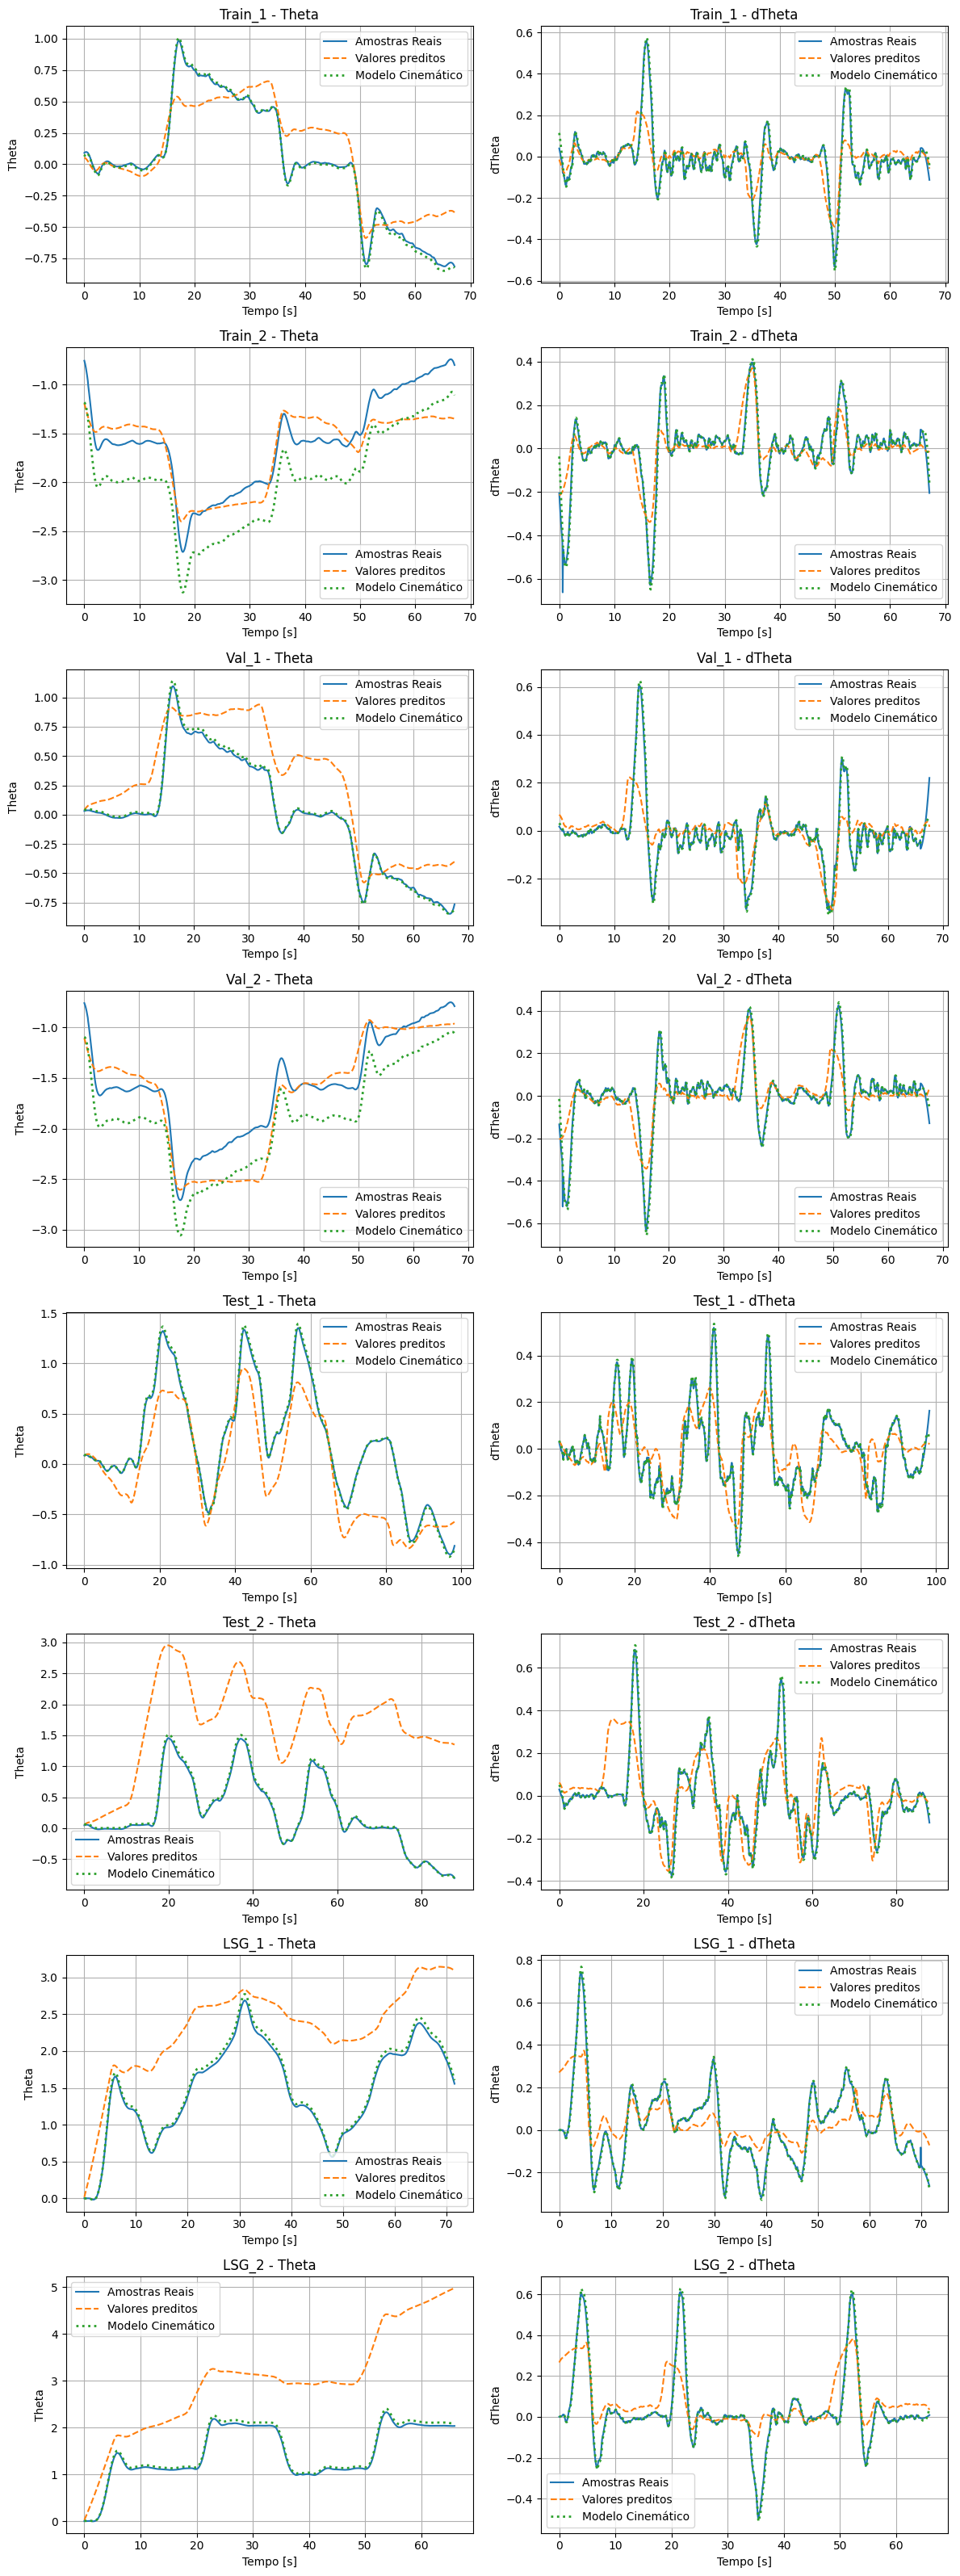

In [26]:
from tensorflow.keras.optimizers import Adam
from itertools import product

N_MODELS = 5
seeds = np.random.choice(range(1, 10000), size=N_MODELS, replace=False)

architectures = [[32],
    [16], [32], [64], [128], [264],
    [8, 4], [16, 8], [32, 16], [64, 32], [128, 64], [264, 128],
    [16, 8, 4], [32, 16, 8], [128, 64, 32], [264, 128, 64]
]

Ld_Lp = [[0.5, 0.5], [0.3,0.7], [0.7,0.3]]
r_values = [0.01, 0.9]

results = {}
# produto cartesiano de todos hiperparâmetros
for arch, (Ld, Lp), r in product(architectures, Ld_Lp, r_values):

    for i, s in enumerate(seeds):
        s = 42
        tf.keras.backend.clear_session()
        np.random.seed(s)
        tf.random.set_seed(s)
        
        initializer = tf.keras.initializers.GlorotUniform(seed=s)
        recurrent_initializer = tf.keras.initializers.Orthogonal(seed=s)

        l2_reg = tf.keras.regularizers.l2(1e-4)

        model = BuildRNN(arch, recurrent_initializer, initializer, l2_reg)
        model.build((None, TIME_STEPS, INPUT_SIZE))

        opt = Adam(learning_rate=1e-3)
        opt.build(model.trainable_variables)

        TrainPINN(
            model,
            Ld=Ld,
            Lp=Lp,
            optimizer=opt,
            epochs=300,
            Es=True,
            patience=50)
        
        model_name = f"model_arch{'-'.join(map(str, arch))}_r{r}_Ld{Ld}_Lp{Lp}_seed{s}"
        ExportModel(model, model_name=model_name)
        metrics = EvalModel(model)
        UpdateRow(metrics, arch, Ld, Lp, r, s, excel_file="resultados.xlsx")
        break
    break